# 🍳 Recipe 02 — Sentiment Analysis Pipeline

> **AI Cookbook** by [Poorvi Bajpai](https://github.com/poorvibajpai)

---

## 🎯 What you'll learn
- What sentiment analysis is and why it matters
- How to use a Hugging Face pipeline in 3 lines of code
- Build a reusable `analyze_sentiment()` function
- Batch inference on a mini review dataset
- Visualize results with matplotlib
- When to use a local model vs an LLM

**Library:** HuggingFace `transformers`, `pandas`, `matplotlib`
**Model:** `distilbert-base-uncased-finetuned-sst-2-english`

---

## 🧠 What is Sentiment Analysis?

Sentiment analysis predicts whether text is **positive** or **negative**, with a confidence score.

**Real-world uses:**
- Analyzing product reviews at scale
- Monitoring brand mentions on social media
- Filtering customer support tickets by urgency

**How it works:**
```
Input Text → Tokenizer → DistilBERT → POSITIVE/NEGATIVE + score
```

The model is fine-tuned DistilBERT trained on Stanford Sentiment Treebank (SST-2).

---

In [ ]:
# Uncomment and run once if needed
# !pip install transformers torch pandas matplotlib

In [2]:
import sys
!{sys.executable} -m pip install transformers torch pandas matplotlib

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6

In [3]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt

print('✅ Libraries imported!')

c:\Users\poorv\anaconda3\envs\ai-cookbook\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported!


---
## 📌 Part 1 — Load the Pipeline

Hugging Face `pipeline()` handles tokenization, inference, and decoding in one call.

First run downloads the model (~250MB). Later runs load instantly from local cache.

In [4]:
classifier = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english'
)

print('✅ Model loaded!')

c:\Users\poorv\anaconda3\envs\ai-cookbook\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\poorv\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2414.03it/s]


✅ Model loaded!


---
## 📌 Part 2 — Single Text Predictions

Test on a few examples to understand the output format.

In [6]:
texts = [
    'I absolutely loved this course. It was clear and practical.',
    'The UI looks good but the app crashes too often.',
    'This was the worst customer support experience ever.',
    'Pretty decent overall, but could be faster.',
    'Excellent product. I would recommend it to everyone.'
]

for text in texts:
    result = classifier(text)[0]
    emoji = '😊' if result['label'] == 'POSITIVE' else '😞'
    print(f"{emoji} [{result['label']} | {result['score']:.4f}]")
    print(f'   {text}')
    print()

😊 [POSITIVE | 0.9999]
   I absolutely loved this course. It was clear and practical.

😞 [NEGATIVE | 0.9996]
   The UI looks good but the app crashes too often.

😞 [NEGATIVE | 0.9998]
   This was the worst customer support experience ever.

😊 [POSITIVE | 0.9959]
   Pretty decent overall, but could be faster.

😊 [POSITIVE | 0.9998]
   Excellent product. I would recommend it to everyone.



### 🔍 Observation
Output = **label** (`POSITIVE`/`NEGATIVE`) + **score** (confidence 0–1).

Mixed reviews still get classified — the model picks the dominant signal.

---
## 📌 Part 3 — Reusable Function

In [7]:
def analyze_sentiment(text):
    """Returns label and confidence score for a given text."""
    result = classifier(text)[0]
    return {
        'text': text,
        'label': result['label'],
        'score': round(result['score'], 4)
    }

# Quick test
analyze_sentiment('The camera quality is amazing, but the battery is disappointing.')

{'text': 'The camera quality is amazing, but the battery is disappointing.',
 'label': 'NEGATIVE',
 'score': 0.9964}

---
## 📌 Part 4 — Batch Inference on Mini Dataset

Run on 10 product reviews and store results in a pandas DataFrame.

In [8]:
reviews = [
    'The laptop is super fast and battery life is amazing.',
    'Delivery was late and the box was damaged.',
    'The phone camera is great, but the phone heats up quickly.',
    'I am very happy with this purchase.',
    'Terrible experience. I want a refund.',
    'The build quality feels premium.',
    'Not worth the money at all.',
    'Customer support solved my issue quickly.',
    'The software is confusing and very buggy.',
    'This is one of the best books I have read this year.'
]

results = [analyze_sentiment(r) for r in reviews]
df = pd.DataFrame(results)
df

,text,label,score
0,The laptop is super fast and battery life is a...,POSITIVE,0.9998
1,Delivery was late and the box was damaged.,NEGATIVE,0.9996
2,"The phone camera is great, but the phone heats...",POSITIVE,0.9926
3,I am very happy with this purchase.,POSITIVE,0.9999
4,Terrible experience. I want a refund.,NEGATIVE,0.9993
5,The build quality feels premium.,POSITIVE,0.9987
6,Not worth the money at all.,NEGATIVE,0.9998
7,Customer support solved my issue quickly.,POSITIVE,0.7982
8,The software is confusing and very buggy.,NEGATIVE,0.9998
9,This is one of the best books I have read this...,POSITIVE,0.9998


In [9]:
print('Sentiment counts:')
print(df['label'].value_counts())
print(f"\nAverage confidence: {df['score'].mean():.4f}")
print(f"\nMost confident prediction:")
print(df.loc[df['score'].idxmax()])

Sentiment counts:
label
POSITIVE    6
NEGATIVE    4
Name: count, dtype: int64

Average confidence: 0.9788

Most confident prediction:
text     I am very happy with this purchase.
label                               POSITIVE
score                                 0.9999
Name: 3, dtype: object


---
## 📌 Part 5 — Visualize Results

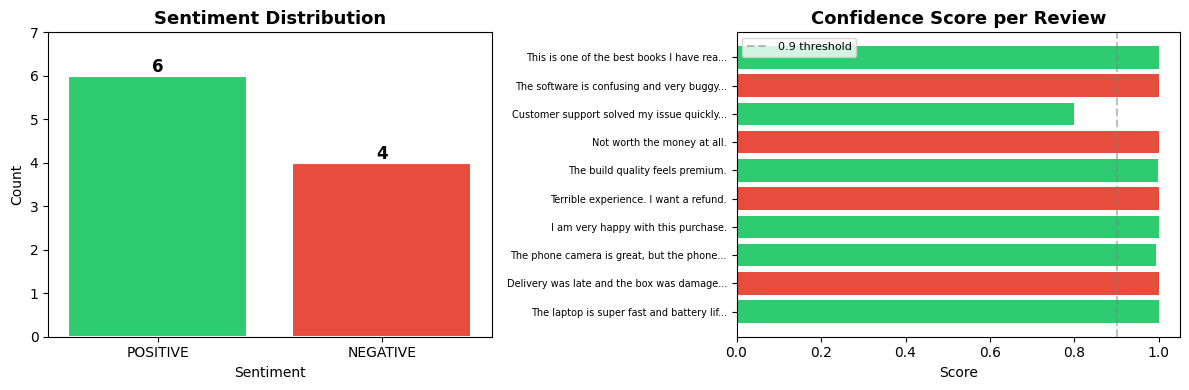

✅ Chart saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
colors = ['#2ecc71' if l == 'POSITIVE' else '#e74c3c' for l in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].bar_label(bars, fontsize=12, fontweight='bold')
axes[0].set_title('Sentiment Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(counts.values) + 1)

bar_colors = ['#2ecc71' if l == 'POSITIVE' else '#e74c3c' for l in df['label']]
axes[1].barh(range(len(df)), df['score'], color=bar_colors)
axes[1].set_yticks(range(len(df)))
axes[1].set_yticklabels([t[:40]+'...' if len(t) > 40 else t for t in df['text']], fontsize=7)
axes[1].set_title('Confidence Score per Review', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].axvline(x=0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 threshold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('sentiment_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

---
## 📌 Part 6 — Local Model vs LLM

| | Local Transformer | LLM (Recipe 01) |
|---|---|---|
| **Speed** | Fast — runs locally | Slower — API call |
| **Cost** | Free after download | API credits |
| **Consistency** | Same output every run | May vary |
| **Flexibility** | Single task only | Multi-task, explanations |
| **Best for** | Repeated classification at scale | Nuanced reasoning |

**Rule of thumb:** Use local classifier for fixed, repeated tasks. Use LLM when you need flexibility or multi-step reasoning.

---

## 📝 Key Takeaways

- `pipeline('sentiment-analysis')` = NLP inference in 3 lines, no training needed
- Output = **label** + **confidence score**
- First run downloads model; later runs use local cache
- Function + DataFrame = production-ready pattern
- Visualization makes your notebook stand out in a portfolio

---

**Next Recipe →** `03-rag-app/notebook.ipynb`